In [1]:
import pandas as pd 
import numpy as np

In [3]:
df = pd.read_csv('oil_sales_assignment_dataset.csv')

### Part 1: Data Exploration 

#### Task 1

In [5]:
df.head(3)

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
0,AL BAHA,HM No 57296 GS-CENTER-AL BAHA MAIN RD AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,LARA COCONUT 0.75L TWIN PACK,21-30,2024,12,830.86,30.1,27.6
1,AL KHARJ,HM No 55697 GS-CENTER-AL KHARJ MAIN RD AL K...,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,NAJMA CANOLA 0.5L TWIN PACK,41-50,2024,10,373.10,9.1,41.0
2,RIYADH,HM No 86781 GS-CENTER-RIYADH MAIN RD RIYADH,AL HILAL INDUSTRIES,BAYTNA,SUNFLOWER,0.75L,BAYTNA SUNFLOWER 0.75L ECO,101+,2023,1,171.70,1.7,101.0


In [6]:
df.tail(3)

,city,store_name,manufacturer,brand,class,size,sku,price_bracket,year,month,value_sales,volume_sales,average_price
1997,AL KHARJ,HM No 90740 GS-CENTER-AL KHARJ MAIN RD AL K...,NOVA FOODS,NOUR,SUNFLOWER,2.9L,NOUR SUNFLOWER 2.9L,91-100,2023,8,527.8,5.8,91.0
1998,RIYADH,HM No 52893 GS-CENTER-RIYADH MAIN RD RIYADH,NOVA FOODS,NAJMA,CORN,0.75L,NAJMA CORN 0.75L ECO,61-70,2024,6,305.0,5.0,61.0
1999,JEDDAH,HM No 73689 GS-CENTER-JEDDAH MAIN RD JEDDAH,NAJDI CONSUMER,BAYTNA,COCONUT,1.8L,BAYTNA COCONUT 1.8L ECO,101+,2022,4,181.8,1.8,101.0


#### Task 2

In [7]:
df.shape

(2000, 13)

In [17]:
df.select_dtypes(include=np.number).columns.tolist()

['year', 'month', 'value_sales', 'volume_sales', 'average_price']

In [18]:
df.select_dtypes(exclude='number').columns.tolist() 

['city',
 'store_name',
 'manufacturer',
 'brand',
 'class',
 'size',
 'sku',
 'price_bracket']

* The dataset is compiled with 13 columns by 2000 rows. 
* the categorical and numerical columns are as listed above 

#### Task 3

In [20]:
df.isnull().sum().sum()

np.int64(0)

Thankfully, there are no missing values in the datsets.

#### Task 4

In [21]:
df.describe()

,year,month,value_sales,volume_sales,average_price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2022.990500,6.639500,614.839355,9.972100,60.990230
std,0.820211,3.468942,750.794991,9.862369,29.457029
min,2022.000000,1.000000,6.960000,0.500000,11.000000
25%,2022.000000,4.000000,132.000000,2.900000,37.337500
50%,2023.000000,7.000000,368.320000,7.000000,61.000000
75%,2024.000000,10.000000,794.100000,13.800000,81.000000
max,2024.000000,12.000000,6253.200000,81.700000,140.000000


### Part 2: Data Preparation 

In [34]:
df = df.drop(['sku', 'store_name'], axis=1)
df.head(2)

,city,manufacturer,brand,class,size,price_bracket,year,month,value_sales,volume_sales,average_price
0,AL BAHA,NOVA FOODS,LARA,COCONUT,0.75L,21-30,2024,12,830.86,30.1,27.6
1,AL KHARJ,PALM & GRAIN GROUP,NAJMA,CANOLA,0.5L,41-50,2024,10,373.10,9.1,41.0


In [35]:
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = df.select_dtypes(exclude='number').columns

encoder = OrdinalEncoder()

df[categorical_cols]= encoder.fit_transform(df[categorical_cols])

In [36]:
df.head()

,city,manufacturer,brand,class,size,price_bracket,year,month,value_sales,volume_sales,average_price
0,1.0,5.0,3.0,1.0,3.0,2.0,2024,12,830.86,30.1,27.6
1,2.0,6.0,4.0,0.0,1.0,4.0,2024,10,373.10,9.1,41.0
2,8.0,0.0,0.0,3.0,3.0,0.0,2023,1,171.70,1.7,101.0
3,3.0,6.0,5.0,2.0,2.0,6.0,2022,2,1226.10,20.1,61.0
4,5.0,3.0,5.0,4.0,7.0,8.0,2024,2,996.30,12.3,81.0


### Part 3: Univartiate Linear Regression 

#### Task 1

In [45]:
X = df[['average_price']]
y = df['value_sales']

#### Task 2

In [46]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

#### Task 3

In [47]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Task 4

Sales = b0 + b1 * Avg_Price

#### Task 5

In [49]:
intercept = model.intercept_
coefficient = model.coef_[0]

print(f"Intercept : {intercept:.2f}")
print(f"Coefficient : {coefficient:.2f}")

Intercept : -27.28
Coefficient : 10.51


Sales = -27.28 + 10.51 * Avg_Price
* the sales increase / decreases by 10.51 linearly as the avg_price increase / decreases by a unit  

#### Task 6

In [54]:
from sklearn.metrics import mean_squared_error, r2_score
y_preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_preds))
r2 = r2_score(y_test, y_preds)

print(f"RMSE score : {rmse:.2f}")
print(f"r^2 score : {r2:.2f}")

RMSE score : 674.03
r^2 score : 0.14


#### Task 7

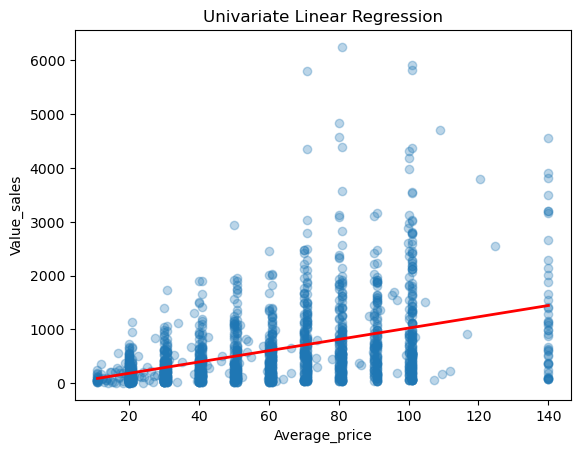

In [57]:
plt.scatter(X_train, y_train, alpha=0.3)

X_sorted = X_train.sort_values("average_price")
y_sorted = model.predict(X_sorted)

plt.plot(
    X_sorted,
    y_sorted,
    color="red",
    linewidth=2
)

plt.xlabel("Average_price")
plt.ylabel("Value_sales")
plt.title("Univariate Linear Regression");

### Part 4: Multivariate Linear regression 

#### Task 1

In [67]:
X2 = df.drop('value_sales', axis=1)
y2 = df['value_sales']

#### Task 2

In [68]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=.2, random_state=42)

#### Task 3

In [69]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X2_train = scaler.fit_transform(X2_train)
X2_test = scaler.transform(X2_test)

#### Task 4

In [70]:
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Task 5

In [72]:
intercept2 = model2.intercept_
print(f"Intercept : {intercept2:.2f}")

Intercept : 617.13


* The intercept represents the predicted value of the target variable when all input features are equal to zero.

#### Task 6

In [74]:
coefficients = pd.DataFrame({
    "features": X2.columns,
    "Coefficient": model2.coef_
})

coefficient['Absolute'] = coefficient["Coefficent"].abs()

coefficient.sort_values(
    "Absolute",
    ascending=False,
    inplace=True
)

IndexError: invalid index to scalar variable.

#### Task 7